# **Data Science**

**Grupo:**
- Miguel Manfré; RM564233
- Vitor Pallis; RM561962
- João Victor; RM563433
- Gabriel Speck; RM562513
- Brenda Thais; RM561258


# Contextualização do problema:

## Problema escolhido

### *Rastreamento orbital e comportamento de satélites*
Principalmente na distribuição de altitudes, inclinações e excentricidades, identificação de outliers (objetos com comportamento orbital atípico) e detecção de sinais de decaimento orbital ao longo do tempo.

## Relevância do problema

A gestão do tráfego espacial e a mitigação de detritos orbitais são cruciais para a sustentabilidade das operações espaciais. Entender a distribuição de órbitas, identificar satélites em risco de reentrada e detectar padrões de comportamento suporta decisões sobre prevenção de colisões, planejamento de janelas de lançamento, regulação de frequências e investimentos em políticas de mitigação.

## Relação com a economia espacial

Operadores comerciais (telecomunicações, observação da Terra, constelações IoT) dependem de alocação eficiente de órbitas e de previsões confiáveis para reduzir custos e riscos. Insights sobre concentrações orbitais, taxas de decaimento e distribuição por operador ajudam a direcionar investimentos, políticas de responsabilidade e serviços de monitoramento impactando diretamente receita,seguro e estratégias operacionais na economia espacial.

## Objetivo da análise

Obejetivo de aplicar estatística descritiva a dados públicos de um CSV do site KAGGLE para:

- Caracterizar distribuições de altitude, inclinação, excentricidade e período orbital.
- Quantificar variabilidade (desvio padrão, CV) e posição (Q1/Q2/Q3, percentis).
- Detectar outliers usando IQR e/ou Z-score e interpretar causas prováveis (decaimento, manobra, objetos incomuns).

Site referência:
https://www.kaggle.com/datasets/karnikakapoor/satellite-orbital-catalog

# Preparação dos Dados
Utilizaremos as bibliotecas em Python:
- Pandas: leitura, limpeza e manipulação de dados
- Numpy: operações numéricas e cálculo de medidas estatísticas.
- Matplotlib: visualizações estatísticas (histogramas, boxplots, scatter).

In [3]:
%pip install pandas; numpy; matplotlib; seaborn

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## Importação das bibliotecas

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Leitura dos Dados

In [5]:
df = pd.read_csv('./df_satelites_limpo.csv')
df.head()

,norad_id,name,object_type,satellite_constellation,altitude_km,altitude_category,orbital_band,congestion_risk,inclination,eccentricity,launch_year_estimate,days_in_orbit_estimate,orbit_lifetime_category,mean_motion,epoch,data_source,snapshot_date,country,last_seen
0,900,CALSPHERE 1,PAYLOAD,Other,975.928822,Low LEO,LEO-Polar,LOW,90.2236,0.002533,2024,0,<1yr,13.766118,2026-06-06 12:07:29.114112,celestrak,2026-06-06,US,2026-06-06
1,902,CALSPHERE 2,PAYLOAD,Other,1061.609076,Mid LEO,LEO-Polar,LOW,90.2377,0.001656,2024,0,<1yr,13.528997,2026-06-06 01:48:16.784064,celestrak,2026-06-06,US,2026-06-06
2,1361,LCS 1,PAYLOAD,Other,2787.867006,High LEO,MEO,LOW,32.1368,0.001240,2024,1,<1yr,9.893107,2026-06-05 11:00:01.893600,celestrak,2026-06-06,US,2026-06-06
3,1512,TEMPSAT 1,PAYLOAD,Other,1133.239326,Mid LEO,LEO-Polar,HIGH,89.9995,0.006763,2024,0,<1yr,13.335935,2026-06-06 11:36:44.059392,celestrak,2026-06-06,US,2026-06-06
4,1520,CALSPHERE 4A,PAYLOAD,Other,1123.182767,Mid LEO,LEO-Polar,HIGH,89.8976,0.007130,2024,0,<1yr,13.362762,2026-06-06 09:00:02.100384,celestrak,2026-06-06,US,2026-06-06


## Inspeção Estrutural

In [6]:
df.shape

(16188, 19)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16188 entries, 0 to 16187
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   norad_id                 16188 non-null  int64  
 1   name                     16188 non-null  object 
 2   object_type              16187 non-null  object 
 3   satellite_constellation  16188 non-null  object 
 4   altitude_km              16188 non-null  float64
 5   altitude_category        16188 non-null  object 
 6   orbital_band             16188 non-null  object 
 7   congestion_risk          16188 non-null  object 
 8   inclination              16188 non-null  float64
 9   eccentricity             16188 non-null  float64
 10  launch_year_estimate     16188 non-null  int64  
 11  days_in_orbit_estimate   16188 non-null  int64  
 12  orbit_lifetime_category  16188 non-null  object 
 13  mean_motion              16188 non-null  float64
 14  epoch                 

## Resumo estatístico

Medidas de tendência central 

- média 
- mediana

Medidas de dispersão

- amplitude
- desvio padrão(std)

Medidas posicionais 

- Q1 
- Q2 
- Q3 
- percentis 

In [8]:
df.describe(percentiles=[0.05,0.25,0.5,0.75,0.95]).T

,count,mean,std,min,5%,25%,50%,75%,95%,max
norad_id,16188.0,58000.102854,8924.268565,900.000000,40971.350000,53206.750000,59610.500000,65064.250000,68469.650000,69328.000000
altitude_km,16188.0,2167.622194,7470.959838,136.628422,346.813331,468.822070,483.051899,558.821574,8065.886404,235127.946482
inclination,16188.0,61.198411,24.178475,0.001700,39.990475,43.004400,53.160100,87.895200,97.650255,150.134700
eccentricity,16188.0,0.002713,0.039362,0.000002,0.000063,0.000117,0.000164,0.000326,0.001451,0.904297
launch_year_estimate,16188.0,2023.992958,0.083625,2023.000000,2024.000000,2024.000000,2024.000000,2024.000000,2024.000000,2024.000000
days_in_orbit_estimate,16188.0,0.582468,1.375390,-2.000000,0.000000,0.000000,0.000000,1.000000,2.000000,30.000000
mean_motion,16188.0,14.402051,3.105099,0.073149,5.001157,15.026198,15.275791,15.323436,15.742335,16.510286


Medidas de dispersão
- variância

In [9]:
df.var(numeric_only=True)

norad_id                  7.964257e+07
altitude_km               5.581524e+07
inclination               5.845987e+02
eccentricity              1.549348e-03
launch_year_estimate      6.993092e-03
days_in_orbit_estimate    1.891697e+00
mean_motion               9.641640e+00
dtype: float64

Medidadas de dispersão
- Coeficiente de variação (CV)

In [10]:
cv = df.std(numeric_only=True, ddof=0) / df.mean(numeric_only=True)
cv_percent = cv * 100
cv_percent

norad_id                    15.386167
altitude_km                344.650885
inclination                 39.507118
eccentricity              1451.044697
launch_year_estimate         0.004132
days_in_orbit_estimate     236.123912
mean_motion                 21.559451
dtype: float64

Medidas de tendência central 

- Moda

In [11]:
df.describe(include='object').T

,count,unique,top,freq
name,16188,16184,OTTER,2
object_type,16187,4,PAYLOAD,15574
satellite_constellation,16188,6,Starlink Gen 1,10792
altitude_category,16188,7,Very Low LEO,9618
orbital_band,16188,8,LEO-Inclined,6798
congestion_risk,16188,3,HIGH,13092
orbit_lifetime_category,16188,2,<1yr,16186
epoch,16188,15240,2026-06-06 06:00:02.000160,538
data_source,16188,1,celestrak,16188
snapshot_date,16188,168,2026-06-06,15630


Análise de outliers 

- IQR 
- Z-Score

In [12]:
variaveis = ['altitude_km', 'inclination', 'eccentricity', 'mean_motion']

resultado_iqr = []

for col in variaveis:
    serie = pd.to_numeric(df[col], errors='coerce').dropna()
    
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    
    resultado_iqr.append({
        'variavel': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'qtd_outliers': outliers.shape[0]
    })

tabela_iqr = pd.DataFrame(resultado_iqr)
tabela_iqr


,variavel,q1,q3,iqr,limite_inferior,limite_superior,qtd_outliers
0,altitude_km,468.822070,558.821574,89.999504,333.822815,693.820830,3168
1,inclination,43.004400,87.895200,44.890800,-24.331800,155.231400,0
2,eccentricity,0.000117,0.000326,0.000209,-0.000197,0.000640,2371
3,mean_motion,15.026198,15.323436,0.297238,14.580341,15.769293,3174


In [13]:
variaveis = ['altitude_km', 'inclination', 'eccentricity', 'mean_motion']

resultado_z = []

for col in variaveis:
    serie = pd.to_numeric(df[col], errors='coerce').dropna()
    
    z = (serie - serie.mean()) / serie.std(ddof=1)
    outliers_z = serie[np.abs(z) > 3]

    resultado_z.append({
        'variavel': col,
        'qtd_outliers_z': outliers_z.shape[0]
    })

tabela_z = pd.DataFrame(resultado_z)
tabela_z

,variavel,qtd_outliers_z
0,altitude_km,630
1,inclination,5
2,eccentricity,53
3,mean_motion,826


## Valores ausentes

In [14]:
missing = df.isnull().sum()
missing_percent = missing / len(df) * 100
pd.concat([missing, missing_percent], axis=1, keys=['missing','percent'])

,missing,percent
norad_id,0,0.000000
name,0,0.000000
object_type,1,0.006177
satellite_constellation,0,0.000000
altitude_km,0,0.000000
altitude_category,0,0.000000
orbital_band,0,0.000000
congestion_risk,0,0.000000
inclination,0,0.000000
eccentricity,0,0.000000


## Duplicatas e identificadores

In [15]:
df[df.duplicated(keep=False)].head()
df['norad_id'].nunique(), df['norad_id'].value_counts().head()

(16188,
 norad_id
 900      1
 63511    1
 63498    1
 63499    1
 63500    1
 Name: count, dtype: int64)

In [16]:
df['name'].value_counts().head(10)

name
OTTER                      2
BOTAN                      2
CMS-03 (GSAT-7R)           2
ELECTRON KICK STAGE R/B    2
STARLINK-33818             1
STARLINK-33843             1
STARLINK-33792             1
STARLINK-33825             1
STARLINK-33811             1
STARLINK-33583             1
Name: count, dtype: int64

## Correlação entre as variáveis

<AxesSubplot: >

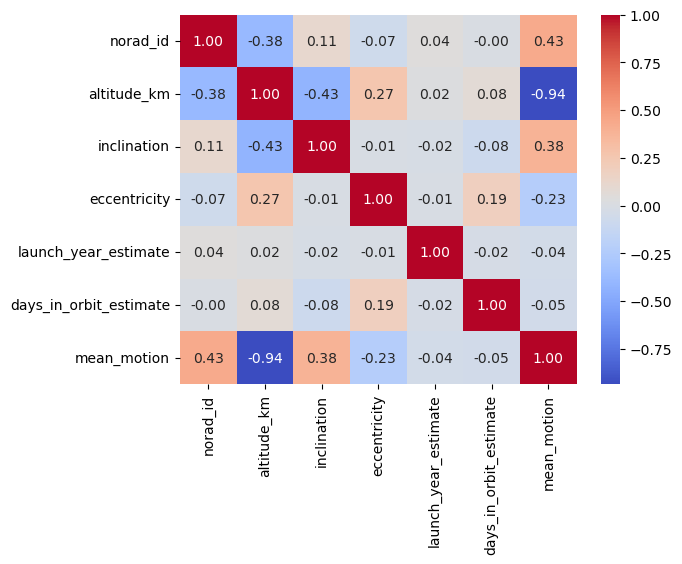

In [17]:
corr = df.select_dtypes('number').corr()
import seaborn as sns; import matplotlib.pyplot as plt
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

## Grafico de barras
Quantidade de satélites por país

In [18]:
df['country'].value_counts().head(10)

country
US     12157
PRC     1406
UK       701
CIS      293
TBD      286
JPN      125
IT        87
IND       74
FR        74
ESA       70
Name: count, dtype: int64

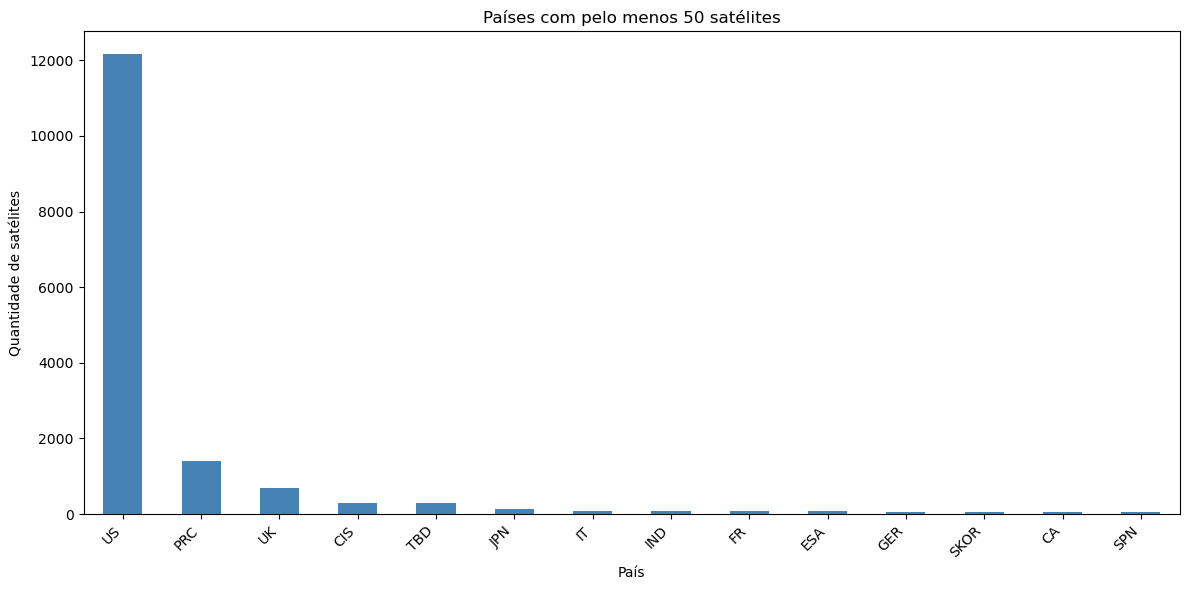

In [19]:
# Contagem de satélites por país
contagem_pais = df['country'].value_counts()

# Defina o mínimo para aparecer no gráfico
min_sat = 50  # ajuste para 5, 10, 20, 50...

# Filtra países com pelo menos min_sat satélites
contagem_filtrada = contagem_pais[contagem_pais >= min_sat].sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(12, 6))
contagem_filtrada.plot(kind='bar', color='steelblue')
plt.title(f'Países com pelo menos {min_sat} satélites')
plt.xlabel('País')
plt.ylabel('Quantidade de satélites')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

as variaveis que apresentam maior variancia são: 

1. altitude_km
2. inclinação
3. mean_motion

não inclui o ID por ele ser unico e obviamente ter a maior variabilidade

In [ ]:
tudo = []
colunas = []

lista_numerica = df.select_dtypes(include='number')  

for column in lista_numerica:
    colunas.append(column)
    colunas.append(df[column].std())
    tudo.append(colunas)
    colunas = []

print("Colunas numéricas e seus desvios padrão:\n")
#esse for mostra as colunas que tem variabilidade numericas.
for i in range(len(tudo)):
    # como o ID é unico por satélite, ele não tem variabilidade, por isso o if.
    if i > 0:
        print(f"{tudo[i][0]}: {tudo[i][1]}")

Colunas numéricas e seus desvios padrão:

altitude_km: 7470.959837720645
inclination: 24.178475287422728
eccentricity: 0.03936175202807886
launch_year_estimate: 0.08362471033623402
days_in_orbit_estimate: 1.3753898801710238
mean_motion: 3.1050990732331125


Existe padrões temporais relevantes? 
 Sim, pois sem saber quantas voltas o satelite da no planeta por dia não daria para medir a velocidade media dele

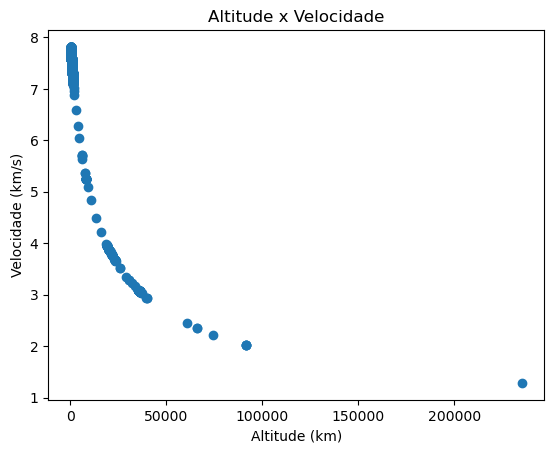

In [42]:
raioSatelite = df["altitude_km"] + 6371
comprimento = 2 * 3.1419 * raioSatelite  

distanciaPercorrida = comprimento * df["mean_motion"]

velocidadeKMS = distanciaPercorrida / (24 * 3600)


plt.scatter(df["altitude_km"], velocidadeKMS)

plt.title("Altitude x Velocidade")
plt.xlabel("Altitude (km)")
plt.ylabel("Velocidade (km/s)")

plt.show()

lista das colunas que possuem maior frequencia ordenadamente

In [84]:
lista = []

for coluna in df.columns:
    frequencia = df[coluna].value_counts().max()
    lista.append((coluna, frequencia))

listaOrdem = sorted(lista, key=lambda x: x[1], reverse=True)

for coluna, frequencia in listaOrdem:
    print(f"{coluna}: {frequencia}")

data_source: 16188
orbit_lifetime_category: 16186
launch_year_estimate: 16074
snapshot_date: 15630
last_seen: 15630
object_type: 15574
congestion_risk: 13092
country: 12157
satellite_constellation: 10792
altitude_category: 9618
days_in_orbit_estimate: 9556
orbital_band: 6798
epoch: 538
inclination: 99
altitude_km: 12
eccentricity: 12
mean_motion: 12
name: 2
norad_id: 1


* Principais achados:

1. A variável altitude apresentou grande variação entre os satélites analisados, indicando que existem satélites operando em diferentes tipos de órbitas, desde órbitas mais baixas até órbitas mais altas.
2. A maioria dos satélites está concentrada em faixas específicas de altitude, mostrando que algumas regiões orbitais são mais utilizadas do que outras.
3. Foram identificados outliers em algumas variáveis numéricas, principalmente em dados relacionados à distribuição orbital, indicando satélites com características muito diferentes da maioria da amostra.
4. O número de órbitas realizadas por dia (mean_motion) varia entre os satélites, onde satélites mais próximos da Terra possuem maior frequência de voltas devido ao menor período orbital.
5. Existe uma relação entre altitude e velocidade orbital, pois a velocidade tende a diminuir conforme a altitude aumenta, devido à maior distância em relação ao centro da Terra.
6. Algumas variáveis possuem maior variabilidade medida pelo desvio padrão, mostrando quais características dos satélites apresentam maior dispersão dentro do conjunto de dados.

* Insights: 

1. Satélites em órbitas mais altas tendem a apresentar diferentes características orbitais quando comparados aos satélites em órbitas mais baixas.
2. A distribuição dos dados mostra que o conjunto possui concentração em alguns padrões de órbita, indicando que certas regiões orbitais são mais utilizadas.
3. A presença de outliers pode indicar satélites com missões específicas ou características fora do padrão da maioria.
4. A análise de correlação permite observar quais variáveis possuem relação entre si, ajudando a entender quais características dos satélites podem estar associadas (como altitude e velocidade orbital).
5. A distribuição dos dados mostra que algumas características são mais comuns entre os satélites analisados, indicando possíveis padrões de projeto ou utilização de determinadas órbitas.


* Aplicações práticas:

1. Auxilia no estudo e classificação de órbitas de satélites.
2. Pode ser usado para identificar dados inconsistentes em bases espaciais.

* Limitações:

1. A análise depende apenas das variáveis disponíveis no dataset.
2. Cálculos de velocidade são estimativas baseadas em suposições (como órbita circular).
3. Não considera fatores como formato da órbita, massa do satélite e perturbações gravitacionais.